In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from image import FruitImage, FruitDataset


In [ ]:
root_dir = "/home/bruno/fing/IA_I/img/"

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)
    if not os.path.isdir(label_path):
        continue
    print(f"\nClase: {label}")
    for filename in os.listdir(label_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            print("  ", filename)


In [ ]:
def show_bgr_image(bgr, title="BGR"):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")


def debug_fruit_mask(
    img_path,
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=5,
):
    fruta = FruitImage(img_path)

    mask = fruta.get_fruit_mask(
        sat_threshold=sat_threshold,
        central_fraction=central_fraction,
        use_bg_hue=use_bg_hue,
        bg_border_frac=bg_border_frac,
        bg_hue_tolerance=bg_hue_tolerance,
    )

    bgr = fruta.bgr
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # overlay: marcamos en rojo los píxeles que la máscara considera fruta
    overlay = rgb.copy()
    overlay[mask] = [255, 0, 0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Máscara fruta")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Original + máscara (rojo = fruta)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Además: mostramos el HSV dominante que devuelve tu función
    h, s, v = fruta.get_dominant_hsv(
        sat_threshold=sat_threshold,
        central_fraction=central_fraction,
    )
    print(f"HSV dominante estimado: H={h:.1f}, S={s:.1f}, V={v:.1f}")


In [ ]:
# Ejemplo con fondo blanco
img_blanco = "/home/bruno/fing/IA_I/img/manzana/manzana_2.png"  # cambia por un archivo real

debug_fruit_mask(
    img_blanco,
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,      # importante que sea 0<frac<1
    bg_hue_tolerance=5,
)


In [ ]:
# Ejemplo con fondo madera
img_madera = "/home/bruno/fing/IA_I/fondo marron/manzana_1.png"  # cambia por un archivo real

debug_fruit_mask(
    img_madera,
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=5,
)


In [ ]:
# Ejemplo con fondo negro
img_negro = "/home/bruno/fing/IA_I/fondo negro/test_m_n.png"  # cambia por un archivo real

debug_fruit_mask(
    img_negro,
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=5,
)

In [ ]:
ds = FruitDataset(root_dir)
ds.build(sat_threshold=40, central_fraction=0.6)
X, y = ds.get_data()

print("Shape X:", X.shape)
print("Clases:", np.unique(y))

for fruta in np.unique(y):
    idx = np.where(y == fruta)[0]
    hues_fruta = X[idx, 0]
    print(f"\nFruta: {fruta}")
    print("  Hues:", np.round(hues_fruta, 1))


=== FONDO BLANCO ===


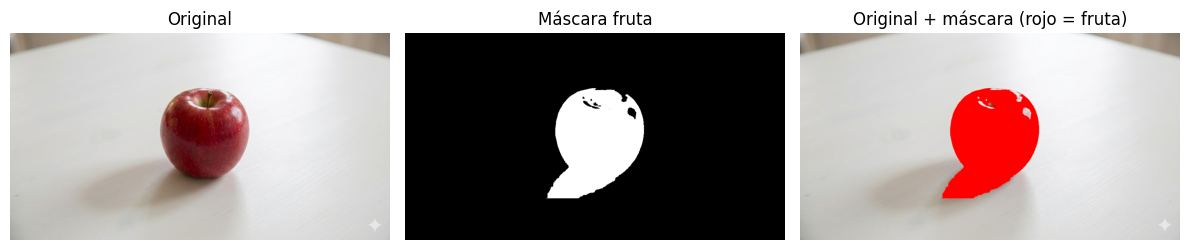

HSV dominante estimado: H=14.0, S=166.0, V=117.0

=== FONDO MADERA ===


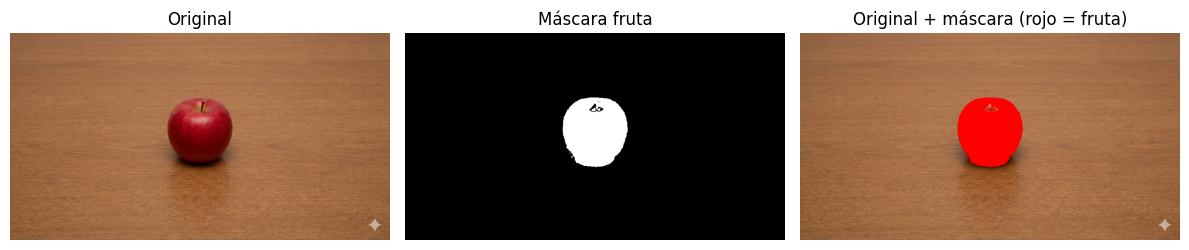

HSV dominante estimado: H=6.0, S=244.0, V=122.0

=== FONDO NEGRO ===


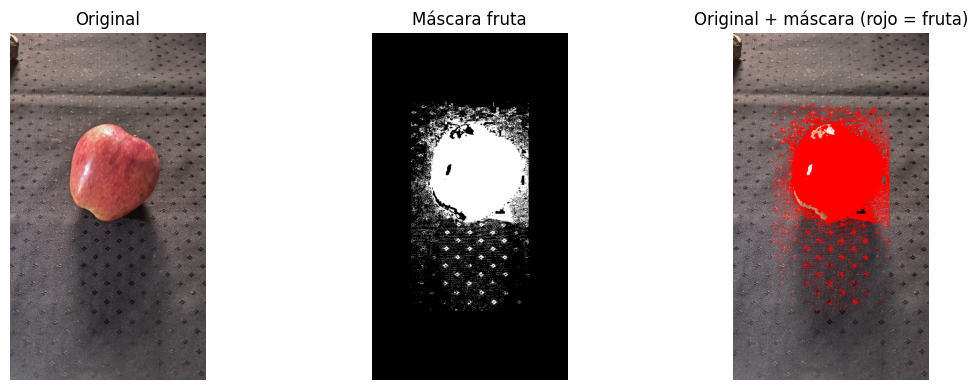

HSV dominante estimado: H=5.0, S=131.0, V=139.0


In [71]:
params = dict(
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=2,
)

print("=== FONDO BLANCO ===")
debug_fruit_mask(img_blanco, **params)

print("\n=== FONDO MADERA ===")
debug_fruit_mask(img_madera, **params)

print("\n=== FONDO NEGRO ===")
debug_fruit_mask(img_negro, **params)

=== FONDO BLANCO ===


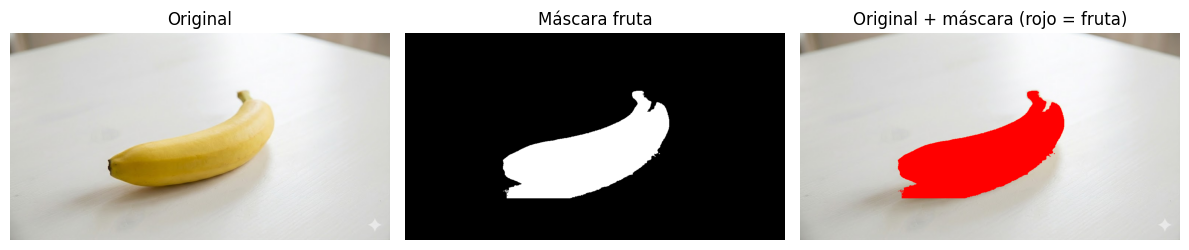

HSV dominante estimado: H=18.0, S=87.0, V=162.0

=== FONDO MADERA ===


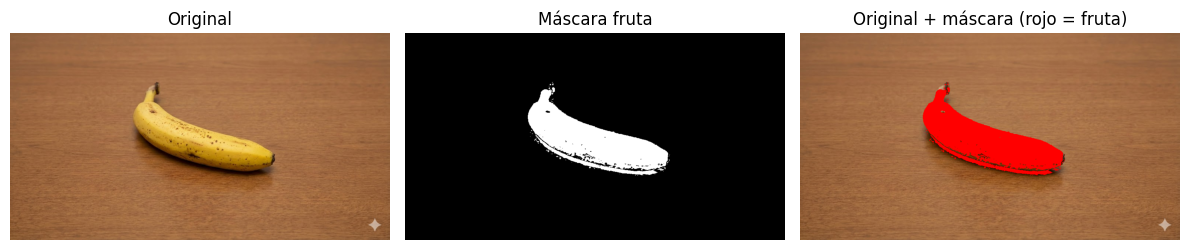

HSV dominante estimado: H=22.0, S=163.0, V=238.0

=== FONDO NEGRO ===


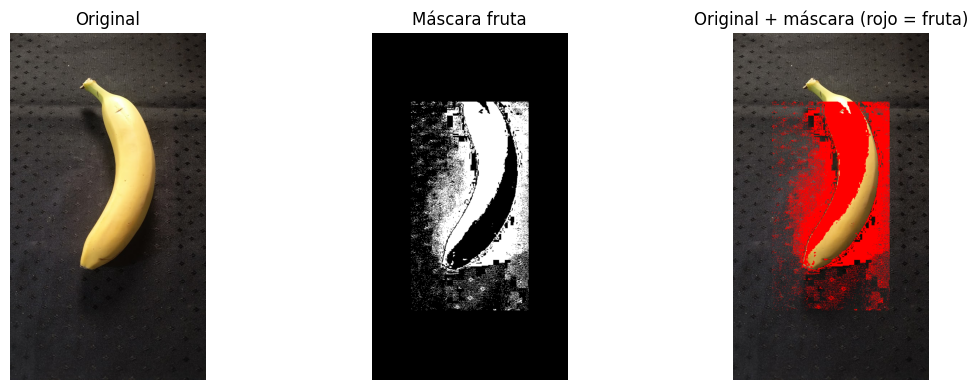

HSV dominante estimado: H=6.0, S=55.0, V=45.0


In [68]:
params = dict(
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=2,
)

print("=== FONDO BLANCO ===")
debug_fruit_mask("/home/bruno/fing/IA_I/img/banana/banana_2.png", **params)

print("\n=== FONDO MADERA ===")
debug_fruit_mask("/home/bruno/fing/IA_I/fondo marron/banana_1.png", **params)

print("\n=== FONDO NEGRO ===")
debug_fruit_mask("/home/bruno/fing/IA_I/fondo negro/test_b_n.png", **params)

=== FONDO BLANCO ===


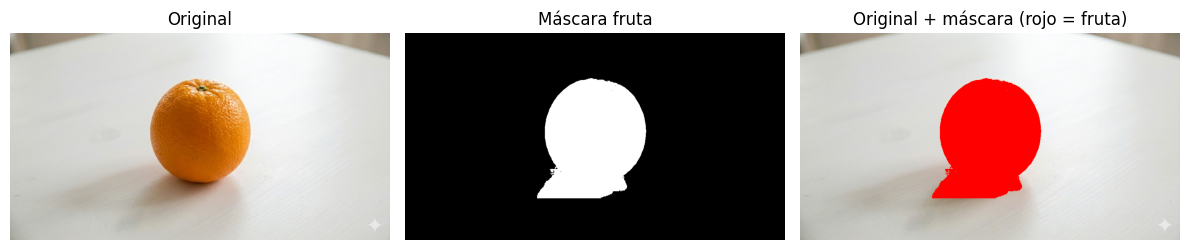

HSV dominante estimado: H=14.0, S=244.0, V=177.0

=== FONDO MADERA ===


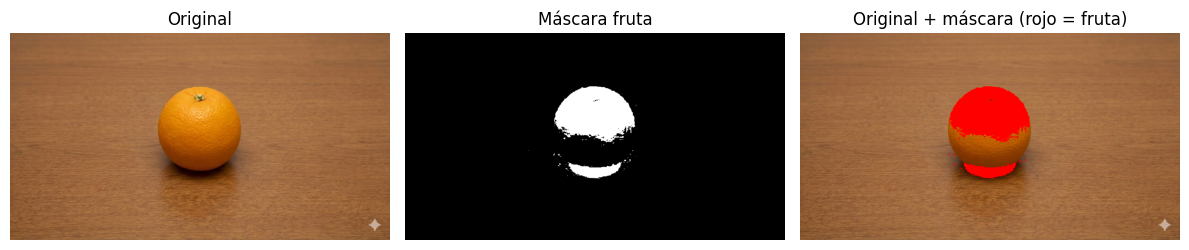

HSV dominante estimado: H=2.0, S=255.0, V=30.0


In [69]:
params = dict(
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=2,
)

print("=== FONDO BLANCO ===")
debug_fruit_mask("/home/bruno/fing/IA_I/img/naranja/narnaja_2.png", **params)

print("\n=== FONDO MADERA ===")
debug_fruit_mask("/home/bruno/fing/IA_I/fondo marron/naranja_1.png", **params)

# print("\n=== FONDO NEGRO ===")
# debug_fruit_mask("/home/bruno/fing/IA_I/fondo negro/test_b_n.png", **params)

=== FONDO BLANCO ===


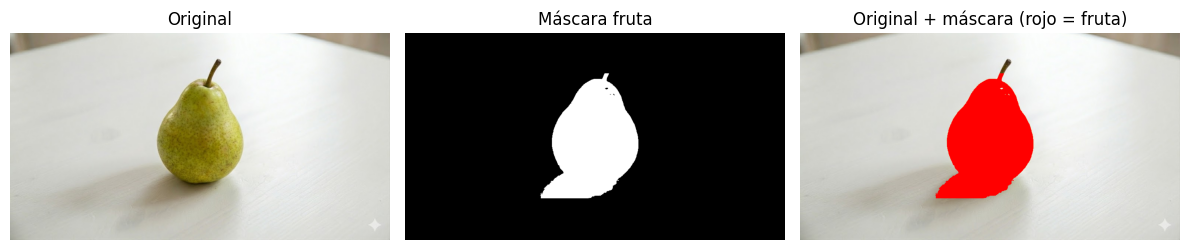

HSV dominante estimado: H=25.0, S=174.0, V=129.0

=== FONDO MADERA ===


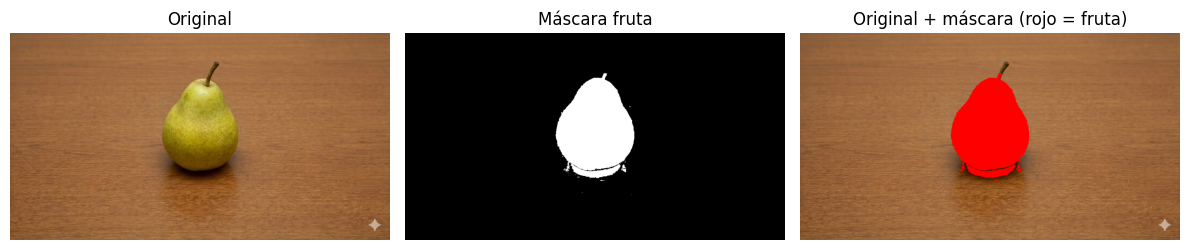

HSV dominante estimado: H=26.0, S=195.0, V=176.0


In [70]:
params = dict(
    sat_threshold=40,
    central_fraction=0.6,
    use_bg_hue=True,
    bg_border_frac=0.1,
    bg_hue_tolerance=2,
)

print("=== FONDO BLANCO ===")
debug_fruit_mask("/home/bruno/fing/IA_I/img/pera/pera_2.png", **params)

print("\n=== FONDO MADERA ===")
debug_fruit_mask("/home/bruno/fing/IA_I/fondo marron/pera_1.png", **params)